In [1]:
import json
import os
import tempfile

import einops
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import wandb
from load_spd_model2 import load_spd_model
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from torch.utils.data import DataLoader
from train_mtsp_model_uniform_task_distribution_modal import TrainConfig
from upload_mtsp_checkpoints_to_wandb import UploadCheckpointsConfig
from wandb_utils import load_wandb_model_artifact

from spd.models.component_model import (
    ComponentModel,
    SPDRunInfo,
    handle_deprecated_state_dict_keys_,
)
from spd.models.components import make_mask_infos
from spd.utils.module_utils import expand_module_patterns

/Users/jack/Desktop/Jack/tests/mats-9/scaling/spd-multitasksparseparity/spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
target_config, config, model = load_spd_model(
    "mutate/multitask-sparse-parity/runs/oniknm0t",  # d_mlp=14, n_control_bits=2, parity=2
    # "wandb:mutate/spd/runs/s-710cd5ea",
    # "wandb:mutate/spd/runs/s-630ccbc4",  # spd-77c2221f-step10000
    # "wandb:mutate/spd/runs/s-e948eb84",  # spd-77c2221f-step20000
    # "wandb:mutate/spd/runs/s-6d5129e4",  # spd-77c2221f-step30000
    # "wandb:mutate/spd/runs/s-80ac5bb0",  # spd-77c2221f-step40000
    # "wandb:mutate/spd/runs/s-3077dc03",  # spd-77c2221f-step50000
    # "wandb:mutate/spd/runs/s-eaff849d",  # spd-77c2221f-step60000
    # # "wandb:mutate/spd/runs/s-d30dc3c8",  # spd-77c2221f-step70000
    # "wandb:mutate/spd/runs/s-a7dcdbfe",  # spd-77c2221f-step80000
    "wandb:mutate/spd/runs/s-6fe153b3",  # spd-77c2221f-step90000
)

wandb: Currently logged in as: row (mutate) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
dataloader = DataLoader(
    MultitaskSparseParityDataset(
        n_control_bits=target_config.n_control_bits,
        n_task_bits=target_config.n_task_bits,
        n_xored_bits=target_config.n_xored_bits,
        task_distribution_decay_rate=target_config.task_distribution_decay_rate,
        batch_sz=1024,
        size=None,
    ),
    batch_size=None,
)
torch.manual_seed(0)
batch = next(iter(dataloader))
task_ids, task_bits, targets = batch

ComponentModel(
  (target_model): MultitaskSparseParityModel(
    (l1): Linear(in_features=32, out_features=14, bias=False)
    (l2): Linear(in_features=14, out_features=2, bias=False)
  )
  (_components): ModuleDict(
    (l1): LinearComponents()
  )
  (_ci_fns): ModuleDict(
    (l1): VectorSharedMLPCiFn(
      (layers): Sequential(
        (0): Linear()
        (1): GELU(approximate='none')
        (2): Linear()
      )
    )
  )
)
tensor(6.4960e-08)
tensor([[ -85.3032,  -67.7231],
        [ -90.6693, -107.3244],
        [ -93.0548,  -77.8349],
        [ -97.5399,  -80.8623],
        [ -68.7853,  -85.9496]])
tensor(6.4960e-08)
tensor(0) tensor([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0]) tensor(1)
torch.Size([1024, 200])
torch.Size([1024, 200])
loss_using_components=tensor(7.1782e-05, grad_fn=<NllLossBackward0>)
l1 tensor(0.0077)


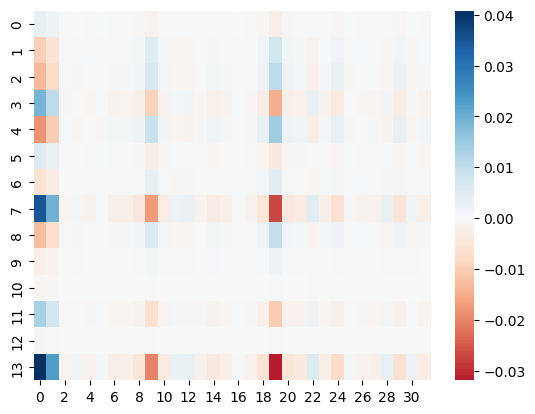

In [4]:
print(model)



loss = F.cross_entropy(model(batch), targets)
print(loss)


out = model(batch, cache_type="input")
print(out.output[:5, :])
loss = F.cross_entropy(out.output, targets)
print(loss)


ci_dict = model.calc_causal_importances(
    pre_weight_acts=out.cache,
    detach_inputs=True,
    sampling=config.sampling,
).lower_leaky

# print(ci_dict)

print(task_ids[0], task_bits[0], targets[0])

print(ci_dict["l1"].shape)

layer_names = list(model.target_module_paths)
ci = torch.cat([ci_dict[layer] for layer in layer_names], dim=1)

print(ci.shape)

component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    # component_masks={k: torch.ones_like(v) for k, v in ci_dict.items()},
    # component_masks={k: v for k, v in ci_dict.items()},
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

# loss_by_token_using_components = F.cross_entropy(
#     einops.rearrange(logits_using_components[:, :-1], "b seq vocab -> b vocab seq"),
#     batch[:, 1:],
#     reduction="none",
# )
# print(f"mean loss using components = {loss_by_token_using_components.mean().item()}")


for k, v in ci_dict.items():
    print(k, (v > component_ci_threshold).float().mean())


components = model.components["l1"]
einops.einsum(components.V[:, 0], components.U[0], "d_in, d_out -> d_out d_in")

idx = 0
sns.heatmap(
    einops.einsum(components.V[:, idx], components.U[idx], "d_in, d_out -> d_out d_in").detach(),
    cmap="RdBu",
    center=0,
)
plt.show()


In [5]:
idx

0

In [6]:
ci.mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([4.8437e-01, 2.1810e-01, 1.8452e-01, 1.8359e-01, 1.5184e-01, 1.4830e-01,
        8.5374e-02, 7.7148e-02, 7.4360e-02, 7.0298e-02, 7.0209e-02, 5.9196e-02,
        4.9073e-02, 1.7986e-02, 1.4968e-02, 1.2348e-02, 9.7895e-04, 7.3596e-04,
        4.0445e-04, 2.9221e-04, 4.0834e-05, 1.2362e-05, 6.8173e-06, 2.0024e-06,
        1.0897e-06, 6.3272e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

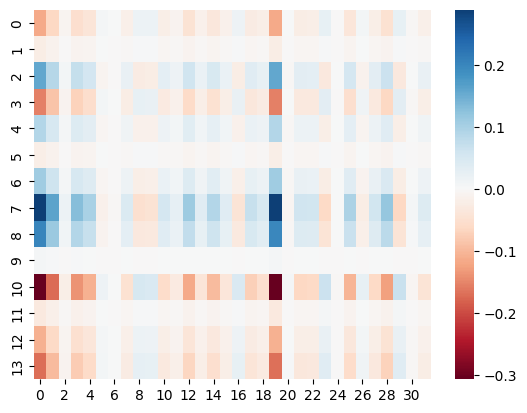

In [7]:
# idx = ci[task_ids == 0].mean(0).sort(descending=True).indices[1]
idx = ci.mean(0).sort(descending=True).indices[1]
# # idx = 73
# idx2 = 2
# print((ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True).values[idx2])
# idx = (ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True).indices[idx2]
sns.heatmap(
    einops.einsum(components.V[:, idx], components.U[idx], "d_in, d_out -> d_out d_in").detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

In [8]:
ci.mean(0).sort(descending=True).values > 0

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

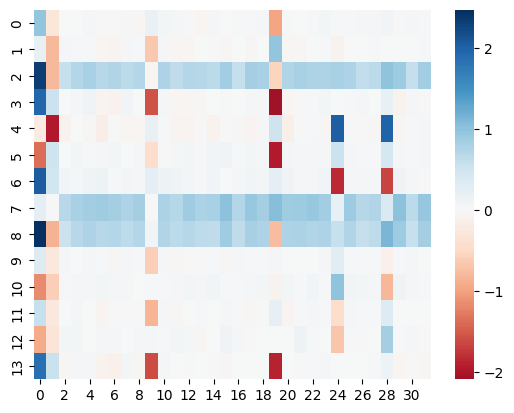

In [9]:
sns.heatmap(
    einops.einsum(
        components.V[:, ci.mean(0) == 0],
        components.U[ci.mean(0) == 0],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

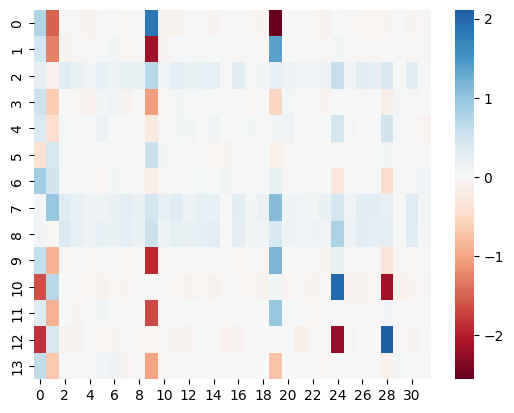

In [10]:
component_mask = ci.mean(0) > 0
sns.heatmap(
    einops.einsum(
        components.V[:, component_mask],
        components.U[component_mask],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

In [11]:
component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    # component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    component_masks={k: (ci.mean(0) > 0.0).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

loss_using_components=tensor(0.0009, grad_fn=<NllLossBackward0>)


In [12]:
(ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([ 1.8452e-01,  1.8359e-01,  1.5184e-01,  1.4830e-01,  9.7895e-04,
         4.0834e-05,  1.0897e-06,  6.3272e-07,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00

In [13]:
ci[:, ci[task_ids == 1].mean(0) == 0][task_ids == 0].mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([2.5193e-01, 2.5067e-01, 2.0731e-01, 2.0248e-01, 1.3366e-03, 5.5752e-05,
        1.4878e-06, 8.6387e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [14]:
(ci[task_ids == 1].mean(0) == 0).shape

torch.Size([200])

In [15]:
# ci[torch.arange(ci.shape[0]), (ci[task_ids == 1].mean(0) == 0)]

In [16]:
ci[task_ids == 0, idx].mean()

tensor(0.1421, grad_fn=<MeanBackward0>)

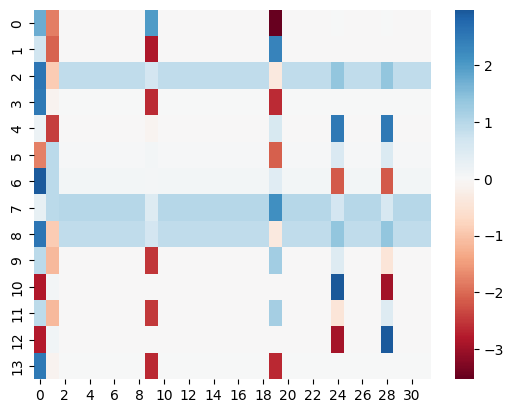

In [17]:
sns.heatmap(
    model.target_model.l1.weight.data,
    cmap="RdBu",
    center=0,
)
plt.show()

In [18]:
ci[task_ids == 0].mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([4.9733e-01, 2.5193e-01, 2.5067e-01, 2.0731e-01, 2.0248e-01, 1.4210e-01,
        1.3366e-03, 3.6960e-04, 5.5752e-05, 3.2710e-05, 1.4878e-06, 8.6387e-07,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [19]:
(ci[task_ids == 0].mean(0) - ci.mean(0)).sort(descending=True)

torch.return_types.sort(
values=tensor([ 6.7410e-02,  6.7073e-02,  5.5471e-02,  5.4180e-02,  1.2957e-02,
         3.5764e-04,  7.7399e-05,  1.4918e-05,  3.9810e-07,  2.3115e-07,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00

In [20]:
task_ids

tensor([0, 0, 1,  ..., 1, 0, 1])

<Axes: >

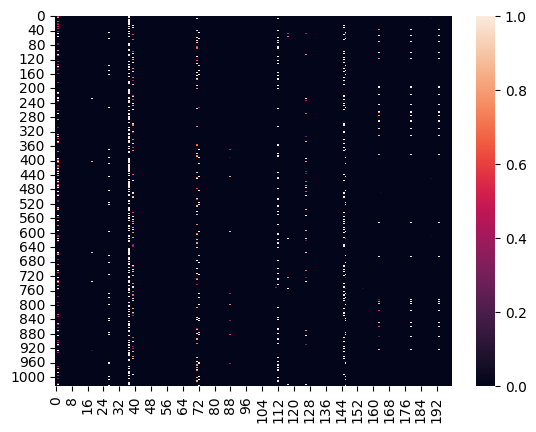

In [21]:
sns.heatmap(ci.detach())

In [22]:
ci.mean(0).sort()

torch.return_types.sort(
values=tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [23]:
component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

loss_using_components=tensor(7.1782e-05, grad_fn=<NllLossBackward0>)


In [24]:
targets

tensor([1, 0, 1,  ..., 0, 1, 1])

In [25]:
ci[3]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7215,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [26]:
logits_using_components

tensor([[-22.1947,   4.2517],
        [ -4.7948, -15.3691],
        [-11.1995,   8.9094],
        ...,
        [ -6.3686, -14.9187],
        [-24.6936,   5.1729],
        [-17.5765,   5.1465]], grad_fn=<MmBackward0>)

In [27]:
from load_spd_model2 import get_steps_to_upload, load_spd_models_for_checkpoints

In [28]:
train_config = TrainConfig()
checkpoints_config = UploadCheckpointsConfig()

models = load_spd_models_for_checkpoints(train_config, checkpoints_config)
steps_list = get_steps_to_upload(train_config, checkpoints_config)

No SPD run found for step 0 (searched for name=spd-a2e3c201-step0), skipping
No SPD run found for step 1000 (searched for name=spd-a2e3c201-step1000), skipping


In [29]:
components = models[steps_list[10]].model.components["l1"]
sns.heatmap(
    einops.einsum(
        components.V[:, :],
        components.U[:],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

IndexError: list index out of range

In [ ]:
def get_ci(model, batch):
    out = model(batch, cache_type="input")
    ci_dict = model.calc_causal_importances(
        pre_weight_acts=out.cache,
        detach_inputs=True,
        sampling=config.sampling,
    ).lower_leaky

    layer_names = list(model.target_module_paths)
    ci = torch.cat([ci_dict[layer] for layer in layer_names], dim=1)
    return ci

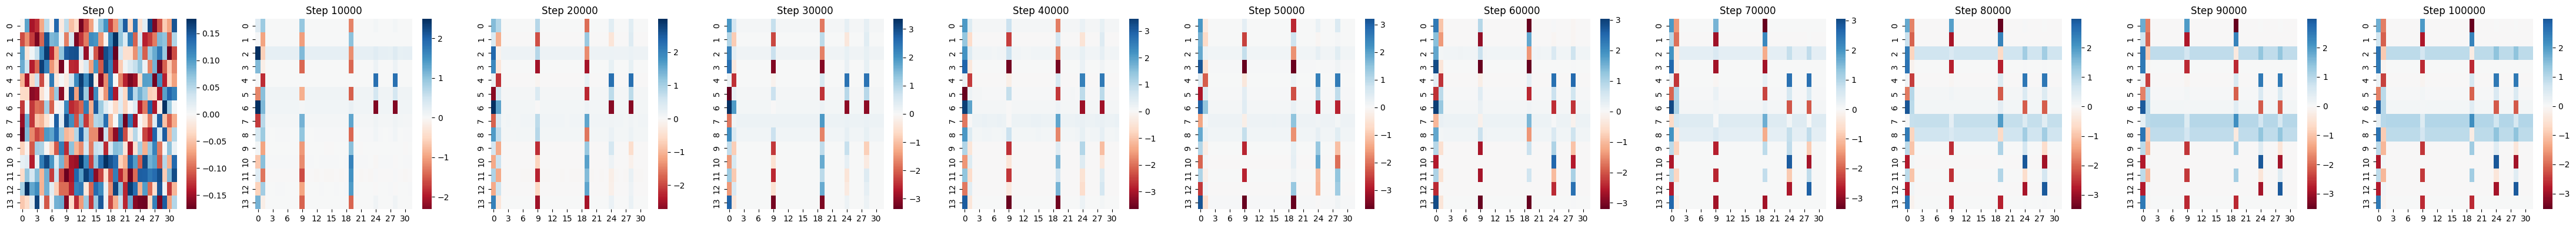

In [ ]:
fig, axes = plt.subplots(1, 11, figsize=(44, 4))
for i, step in enumerate(steps_list):
    components = models[step].model.components["l1"]
    sns.heatmap(
        einops.einsum(
            components.V[:, :],
            components.U[:],
            "d_in c, c d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()

In [ ]:
model = None

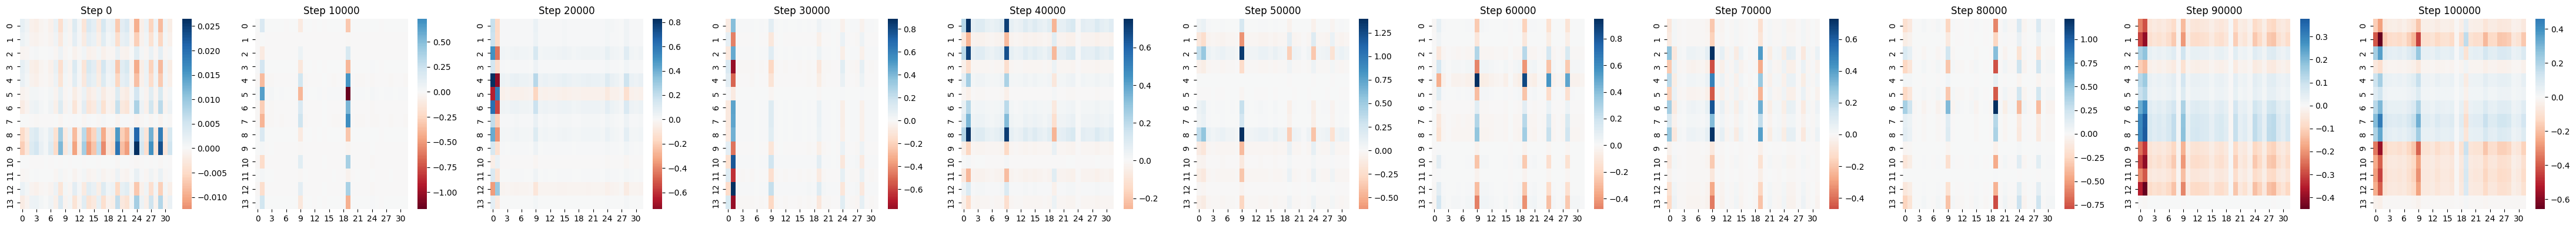

In [ ]:
fig, axes = plt.subplots(1, len(steps_list), figsize=(4 * len(steps_list), 4))
for i, step in enumerate(steps_list):
    components = models[step].model.components["l1"]

    ci = get_ci(models[step].model, batch).detach()
    idx = ci.mean(0).sort(descending=True).indices[0]

    sns.heatmap(
        einops.einsum(
            components.V[:, idx],
            components.U[idx],
            "d_in, d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()

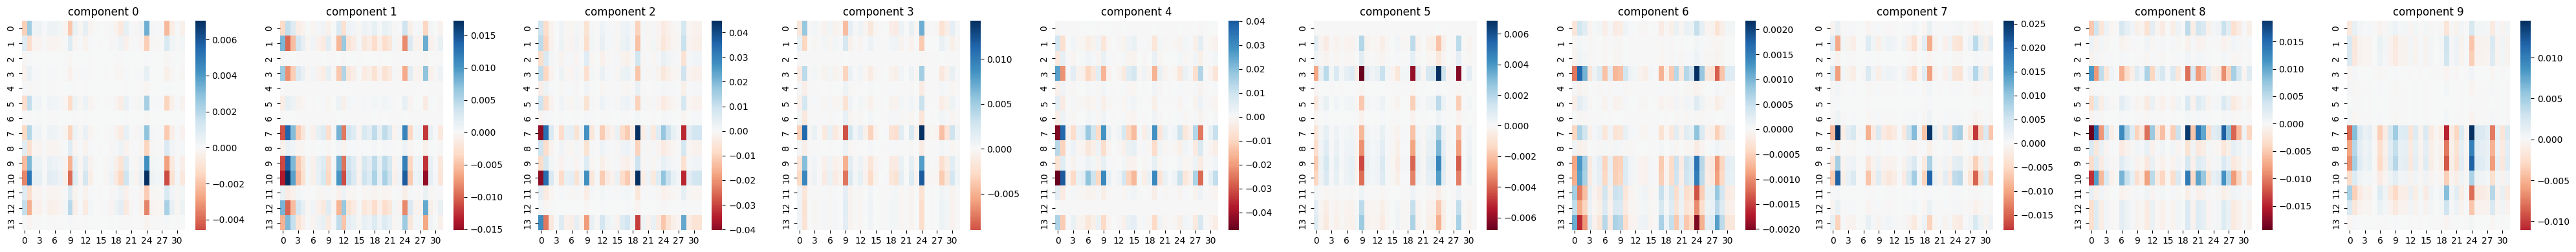

In [ ]:
n = 10
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

components = models[steps_list[2]].model.components["l1"]
components_outer = einops.einsum(
    components.V,
    components.U,
    "d_in c, c d_out -> c d_out d_in",
)

components_outer_normalised = (
    components_outer / (einops.einsum(components_outer**2, "c a b -> c") ** 0.5)[:, None, None]
)
reference_component_normalised = reference_component / (reference_component.pow(2).sum() ** 0.5)
component_sims = einops.einsum(
    components_outer_normalised, reference_component_normalised, "c a b, a b -> c"
)

idxes = component_sims.sort(descending=True).indices

for i in range(n):
    # ci = get_ci(model, batch).detach()
    # idx = ci.mean(0).sort(descending=True).indices[i]
    idx = idxes[i]

    sns.heatmap(
        einops.einsum(
            components.V[:, idx],
            components.U[idx],
            "d_in, d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"component {i}")
plt.tight_layout()
plt.show()

tensor(0.1920, grad_fn=<SelectBackward0>)
tensor(0.5593, grad_fn=<SelectBackward0>)
tensor(0.6051, grad_fn=<SelectBackward0>)
tensor(0.6607, grad_fn=<SelectBackward0>)
tensor(0.3912, grad_fn=<SelectBackward0>)
tensor(0.5871, grad_fn=<SelectBackward0>)
tensor(0.8963, grad_fn=<SelectBackward0>)
tensor(0.9071, grad_fn=<SelectBackward0>)
tensor(0.9263, grad_fn=<SelectBackward0>)
tensor(0.9724, grad_fn=<SelectBackward0>)
tensor(1.0000, grad_fn=<SelectBackward0>)


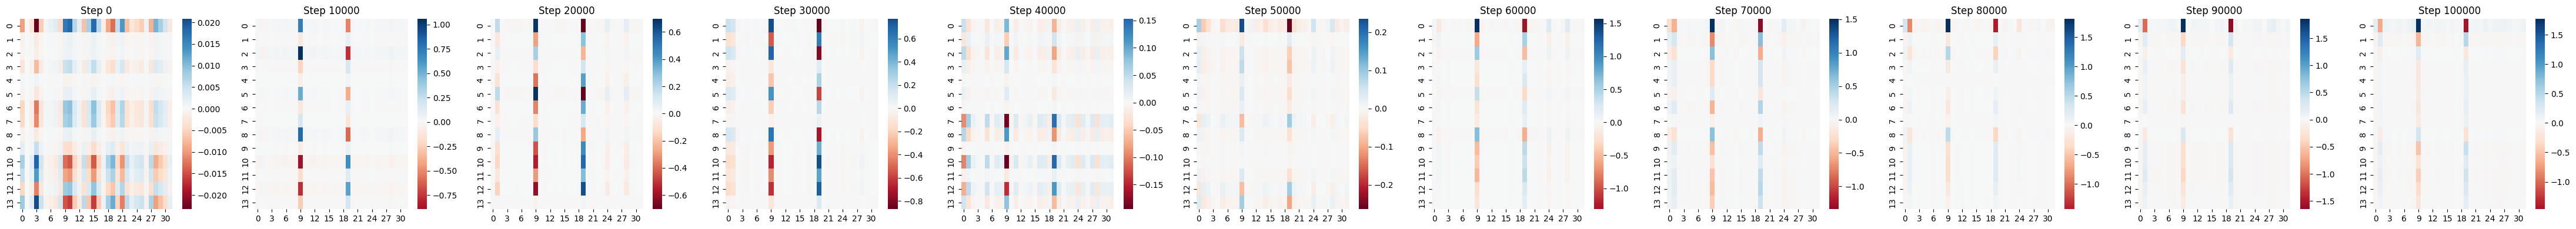

In [ ]:
fig, axes = plt.subplots(1, len(steps_list), figsize=(4 * len(steps_list), 4))
for i, step in enumerate(steps_list):
    components = models[step].model.components["l1"]

    # ci = get_ci(model, batch).detach()
    # idx = ci.mean(0).sort(descending=True).indices[0]

    components_outer = einops.einsum(
        components.V,
        components.U,
        "d_in c, c d_out -> c d_out d_in",
    )

    components_outer_normalised = (
        components_outer / (einops.einsum(components_outer**2, "c a b -> c") ** 0.5)[:, None, None]
    )
    reference_component_normalised = reference_component / (reference_component.pow(2).sum() ** 0.5)
    component_sims = einops.einsum(
        components_outer_normalised, reference_component_normalised, "c a b, a b -> c"
    )
    sims_sorted = component_sims.sort(descending=True)

    idxes = sims_sorted.indices
    idx = idxes[0]
    print(sims_sorted.values[0])

    # print(
    #     (
    #         ((components_outer[idx] > 0) == (reference_component > 0)).float()
    #         * F.softmax(reference_component.flatten() * 12, dim=0).view(reference_component.shape)
    #     ).sum()
    # )
    # if i > 8:
    #     1/0

    sns.heatmap(
        einops.einsum(
            components.V[:, idx],
            components.U[idx],
            "d_in, d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()

In [ ]:
(
    ((components_outer[idx] > 0) == (reference_component > 0)).float()
    * F.softmax(reference_component.flatten() * 10, dim=0).view(reference_component.shape)
).sum()

tensor(0.7506, grad_fn=<SumBackward0>)

tensor(0.)
tensor(1.1758)
tensor(1.3555)
tensor(1.3926)
tensor(1.3076)
tensor(1.2969)
tensor(1.1240)
tensor(1.0322)
tensor(1.1328)
tensor(1.1738)
tensor(1.2256)


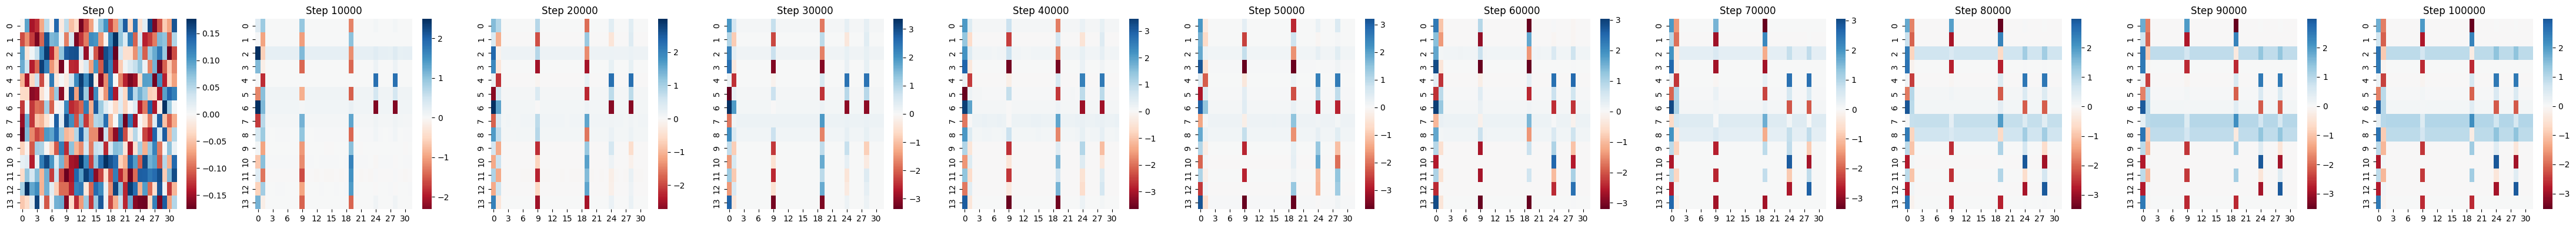

In [ ]:
fig, axes = plt.subplots(1, len(steps_list), figsize=(4 * len(steps_list), 4))
for i, step in enumerate(steps_list):
    model = models[step].model
    components = model.components["l1"]

    ci = get_ci(model, batch).detach()
    # idx = ci.mean(0).sort(descending=True).indices[0]

    components_outer = einops.einsum(
        components.V,
        components.U,
        "d_in c, c d_out -> c d_out d_in",
    )

    component_mask = ci.mean(0) > -1
    # print(component_mask.float().sum())
    print(ci.count_nonzero(1).float().mean())

    sns.heatmap(
        einops.einsum(
            components.V[:, component_mask],
            components.U[component_mask],
            "d_in c, c d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()

tensor(1.2256)

In [ ]:
out = model(batch, cache_type="input")
loss = F.cross_entropy(out.output, targets)
print(loss)

ci_dict = model.calc_causal_importances(
    pre_weight_acts=out.cache,
    detach_inputs=True,
    sampling=config.sampling,
).lower_leaky
component_ci_threshold = 0.
mask_infos = make_mask_infos(
    # component_masks={k: torch.ones_like(v) for k, v in ci_dict.items()},
    # component_masks={k: v for k, v in ci_dict.items()},
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

tensor(6.4378e-08)
loss_using_components=tensor(2.8150e-05, grad_fn=<NllLossBackward0>)


In [ ]:
component_mask.shape

torch.Size([200])

In [ ]:
reference_component > 0

tensor([[ True, False, False, False,  True, False,  True, False, False,  True,
          True,  True, False, False, False, False,  True,  True, False,  True,
         False, False, False, False, False, False, False, False,  True,  True,
         False, False],
        [ True, False, False, False,  True, False,  True, False, False,  True,
          True,  True, False, False, False, False,  True,  True, False,  True,
         False, False, False, False, False, False, False, False,  True,  True,
         False, False],
        [False,  True,  True,  True, False,  True, False,  True,  True, False,
         False, False,  True,  True,  True,  True, False, False,  True, False,
          True,  True,  True,  True,  True,  True,  True,  True, False, False,
          True,  True],
        [False,  True,  True,  True, False,  True, False,  True,  True, False,
         False, False,  True,  True,  True,  True, False, False,  True, False,
          True,  True,  True,  True,  True,  True,  True,  

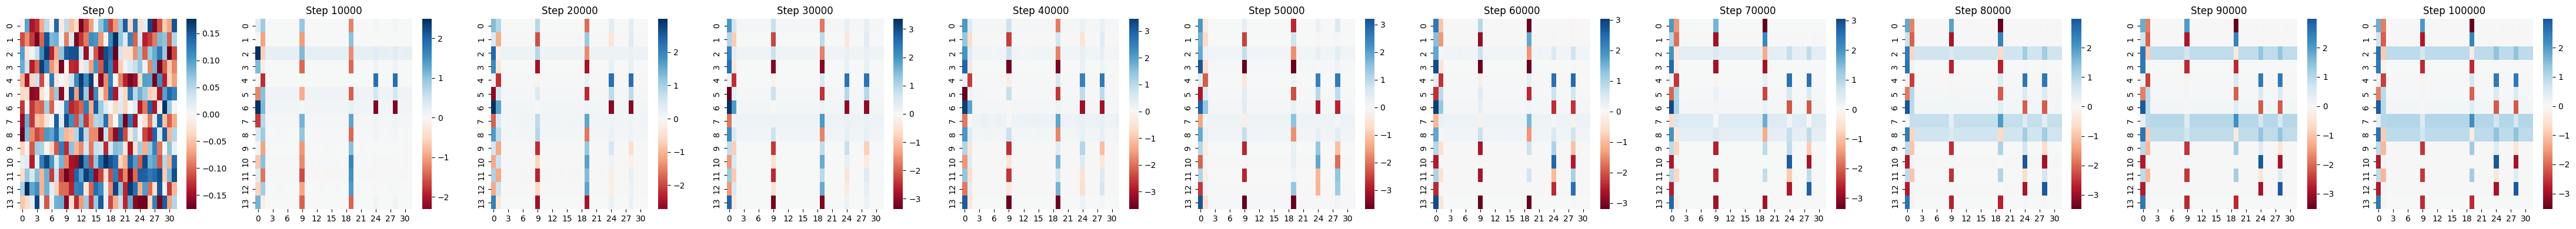

In [ ]:
fig, axes = plt.subplots(1, len(steps_list), figsize=(4 * len(steps_list), 4))
for i, step in enumerate(steps_list):
    sns.heatmap(
        models[step].model.target_model.l1.weight.data.detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()

In [ ]:
component_sims.sort(descending=True)

torch.return_types.sort(
values=tensor([ 1.0000e+00,  3.6668e-01,  3.4834e-01,  3.3548e-01,  3.2970e-01,
         3.1692e-01,  2.5549e-01,  2.5263e-01,  2.4535e-01,  2.4098e-01,
         2.2570e-01,  2.2506e-01,  2.1541e-01,  2.1538e-01,  1.9621e-01,
         1.9243e-01,  1.8283e-01,  1.7750e-01,  1.7138e-01,  1.6964e-01,
         1.6785e-01,  1.6750e-01,  1.6471e-01,  1.5756e-01,  1.5425e-01,
         1.5354e-01,  1.4798e-01,  1.4660e-01,  1.4537e-01,  1.4228e-01,
         1.3704e-01,  1.3703e-01,  1.3610e-01,  1.2908e-01,  1.2838e-01,
         1.2543e-01,  1.2460e-01,  1.2391e-01,  1.1654e-01,  1.1041e-01,
         1.0884e-01,  1.0199e-01,  9.9798e-02,  9.6373e-02,  9.4425e-02,
         8.8038e-02,  8.5763e-02,  8.4684e-02,  8.4627e-02,  8.4161e-02,
         8.0639e-02,  7.7803e-02,  7.6863e-02,  7.6796e-02,  7.5823e-02,
         7.4041e-02,  7.2522e-02,  7.2487e-02,  7.0792e-02,  6.8279e-02,
         6.7053e-02,  6.3876e-02,  6.2697e-02,  6.1500e-02,  6.1412e-02,
         5.5455e-02

In [ ]:
components_outer = einops.einsum(
    components.V,
    components.U,
    "d_in c, c d_out -> c d_out d_in",
)

In [ ]:
components_outer_normalised = (
    components_outer / (einops.einsum(components_outer**2, "c a b -> c") ** 0.5)[:, None, None]
)
reference_component_normalised = reference_component / (reference_component.pow(2).sum() ** 0.5)
einops.einsum(components_outer_normalised, reference_component_normalised, "c a b, a b -> c").min()

tensor(-0.0235, grad_fn=<MinBackward1>)

In [ ]:
components_outer.shape

torch.Size([200, 14, 32])

In [ ]:
(components_outer / (einops.einsum(components_outer**2, "c a b -> c") ** 0.5)[:, None, None]).shape

torch.Size([200, 14, 32])

In [ ]:
components_outer.shape

torch.Size([200, 14, 32])

In [ ]:
(reference_component**2).sum() ** 0.5

tensor(1.6057, grad_fn=<PowBackward0>)

In [ ]:
model = models[100000].model
components = model.components["l1"]
ci = get_ci(model, batch).detach()
idx = ci.mean(0).sort(descending=True).indices[2]

In [ ]:
reference_component = einops.einsum(
    components.V[:, idx],
    components.U[idx],
    "d_in, d_out -> d_out d_in",
)

<Axes: >

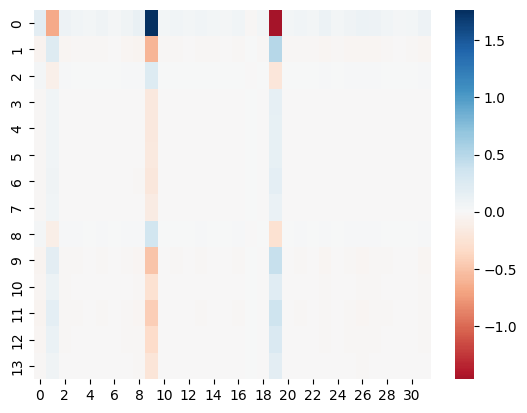

In [ ]:
sns.heatmap(reference_component.detach(), cmap="RdBu", center=0)

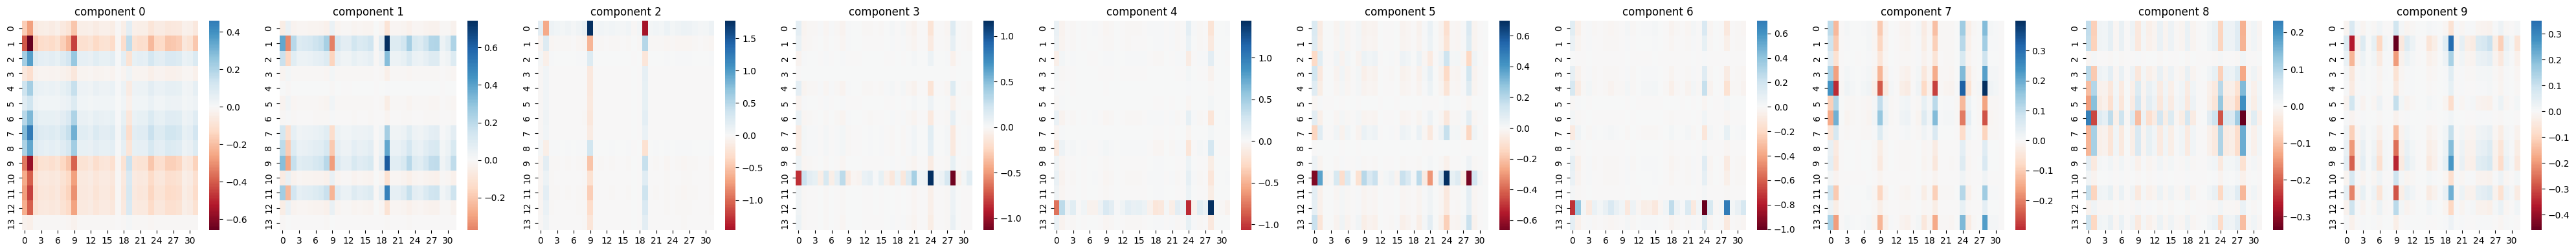

In [ ]:
n = 10
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for i in range(n):
    model = models[steps_list[-1]].model
    components = model.components["l1"]

    ci = get_ci(model, batch).detach()
    idx = ci.mean(0).sort(descending=True).indices[i]

    sns.heatmap(
        einops.einsum(
            components.V[:, idx],
            components.U[idx],
            "d_in, d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"component {i}")
plt.tight_layout()
plt.show()

In [ ]:
ci.mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([4.8438e-01, 1.8251e-01, 1.8090e-01, 7.7148e-02, 7.0312e-02, 6.9719e-02,
        5.4254e-02, 2.4490e-02, 7.7842e-03, 1.2153e-03, 9.3729e-04, 2.1642e-04,
        4.0828e-05, 3.2990e-05, 3.0683e-06, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

NameError: name 'dataset' is not defined

In [ ]:
(ci.mean(0).sort(descending=True).values > 0).sum()

tensor(26)